# [LAB 05] XGBoost Channel 분류 및 TabPy 배포
## 구매 패턴 기반 고객 군집 노트북과 동일 전처리 → Channel(1/2) 예측

- **전처리**: LAB 05와 동일 (np.log1p → StandardScaler, 6개 로그 스케일 컬럼 사용)
- **타겟**: Channel (1 또는 2) → 라벨 0/1로 변환하여 이진 분류
- **모델**: XGBoost 분류기
- **저장**: scaler, XGB 모델 각각 pkl 저장 → TabPy/Tableau 시뮬레이터 연동

## 1. 라이브러리 및 데이터 로드

In [61]:
from hossam import load_data
import pandas as pd
import numpy as np
from pandas import DataFrame
from matplotlib import pyplot as plt
import seaborn as sb

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    roc_curve,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
)
import xgboost as xgb
import pickle
from pathlib import Path

my_dpi = 200
RAW_COLS = ['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen','Region']
LAB05_DIR = Path('.').resolve()

In [62]:
origin = load_data('wholesale_customers')
df = origin[RAW_COLS + ['Channel']].copy()
df.head(10)

이 데이터 세트는 도매 유통업체의 고객 정보를 담고 있습니다. 다양한 제품 카테고리에 대한 연간 지출액(mu, 화폐 단위)을 포함합니다. (출처: https://www.kaggle.com/datasets/binovi/wholesale-customers-data-set)

컬럼명            의미                  설명
----------------  --------------------  --------------------------------------------------------------------------------------------
Channel           유통 채널             고객의 거래 채널을 나타냄. 주로 Horeca(호텔·레스토랑·카페) 또는 Retail(소매점) 구분에 사용됨
Region            지역                  고객이 속한 지리적 지역 구분 변수. 특정 국가 내의 권역 정보
Fresh             신선식품 구매액       육류, 채소, 과일 등 신선식품 카테고리에 대한 연간 구매 금액
Milk              유제품 구매액         우유, 치즈, 요거트 등 유제품 카테고리에 대한 연간 구매 금액
Grocery           식료품 구매액         가공식품, 일반 식료품 등 장기 보관 식품 카테고리 구매 금액
Frozen            냉동식품 구매액       냉동 육류, 냉동 가공식품 등 냉동식품 카테고리 구매 금액
Detergents_Paper  세제·종이류 구매액    세제, 화장지, 키친타월 등 생활 소모품 구매 금액
Delicassen        즉석·가공식품 구매액  즉석식품, 델리 식품, 가공 반찬류 등의 구매 금액



,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,Region,Channel
0,12669,9656,7561,214,2674,1338,3,2
1,7057,9810,9568,1762,3293,1776,3,2
2,6353,8808,7684,2405,3516,7844,3,2
3,13265,1196,4221,6404,507,1788,3,1
4,22615,5410,7198,3915,1777,5185,3,2
5,9413,8259,5126,666,1795,1451,3,2
6,12126,3199,6975,480,3140,545,3,2
7,7579,4956,9426,1669,3321,2566,3,2
8,5963,3648,6192,425,1716,750,3,1
9,6006,11093,18881,1159,7425,2098,3,2


## 2. 전처리 (LAB 05와 동일: log1p → StandardScaler)

1. 원본 6컬럼에 **np.log1p** 적용하여 log_ 컬럼 추가  
2. **StandardScaler**로 12컬럼(원본+log) 표준화  
3. 학습에는 **스케일된 log 6컬럼**만 사용 (기존 PCA 입력과 동일)

In [63]:
df_log = df[RAW_COLS].copy()
for c in RAW_COLS:
    df_log[f'log_{c}'] = np.log1p(df_log[c])
# Region: 범주형(1,2,3) → 원핫 인코딩 (drop_first=True → Region_2, Region_3)
region_dummies = pd.get_dummies(df['Region'], prefix='Region', drop_first=True)
df_log = pd.concat([df_log, region_dummies], axis=1)

scaler = StandardScaler()
sdf = DataFrame(scaler.fit_transform(df_log), columns=df_log.columns)
log_cols = [f'log_{c}' for c in RAW_COLS]
FEATURE_COLS = log_cols + list(region_dummies.columns)  # 8개: log 6 + Region 더미 2
X = sdf[FEATURE_COLS].values
y = (df['Channel'] - 1).values  # 1,2 → 0,1

print('X shape:', X.shape)
print('y unique:', np.unique(y))
X[:3]

X shape: (440, 7)
y unique: [0 1]


array([[ 0.4861845 ,  0.97629884,  0.44015468, -1.50924981,  0.64414327,
         0.40896595,  0.57541729],
       [ 0.08788863,  0.99095612,  0.65217085,  0.13405226,  0.76604314,
         0.62792606,  0.57541729],
       [ 0.01635628,  0.89115098,  0.45468702,  0.37689926,  0.80440496,
         1.77683339,  0.57541729]])

## 3. train/test split 및 XGBoost 학습

In [64]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=52, stratify=y
)

clf = xgb.XGBClassifier(random_state=52, use_label_encoder=False, eval_metric='logloss')
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
y_pred_proba = clf.predict_proba(X_test)
y_pred_proba_1 = y_pred_proba[:, 1]  # 양성(Channel=2) 확률

c:\Users\bohee\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:199: UserWarning: [15:20:25] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


## 4. 성능 지표: Accuracy, Confusion Matrix, ROC-AUC

In [65]:
acc = accuracy_score(y_test, y_pred)
print('Accuracy:', acc)
print('Precision:', precision_score(y_test, y_pred, zero_division=0))
print('Recall:', recall_score(y_test, y_pred, zero_division=0))
print('F1:', f1_score(y_test, y_pred, zero_division=0))
print('ROC-AUC:', roc_auc_score(y_test, y_pred_proba_1))

Accuracy: 0.8818181818181818
Precision: 0.9230769230769231
Recall: 0.6857142857142857
F1: 0.7868852459016393
ROC-AUC: 0.931047619047619


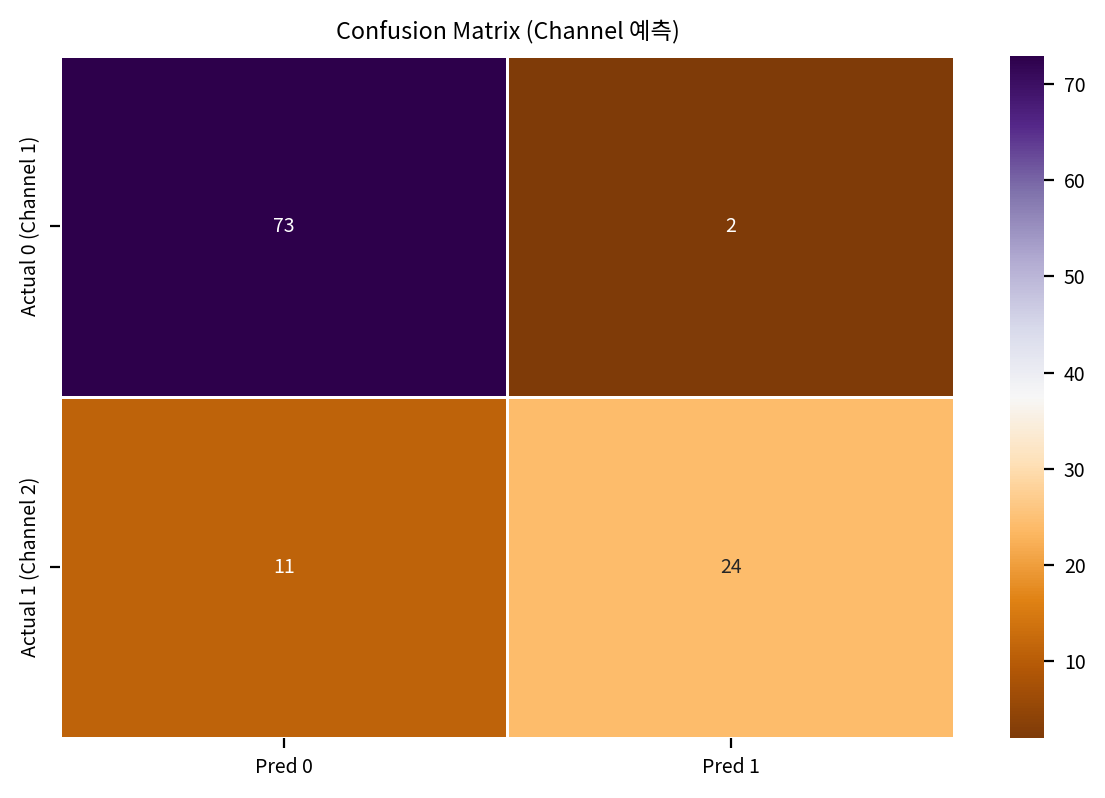

,Pred 0,Pred 1
Actual 0 (Channel 1),73,2
Actual 1 (Channel 2),11,24


In [66]:
cm = confusion_matrix(y_test, y_pred)
cmdf = DataFrame(
    cm,
    index=['Actual 0 (Channel 1)', 'Actual 1 (Channel 2)'],
    columns=['Pred 0', 'Pred 1']
)
fig, ax = plt.subplots(1, 1, figsize=(6, 4), dpi=my_dpi)
sb.heatmap(cmdf, annot=True, fmt='d', linewidths=0.5, cmap='PuOr')
ax.set_title('Confusion Matrix (Channel 예측)')
plt.tight_layout()
plt.show()
plt.close()
cmdf

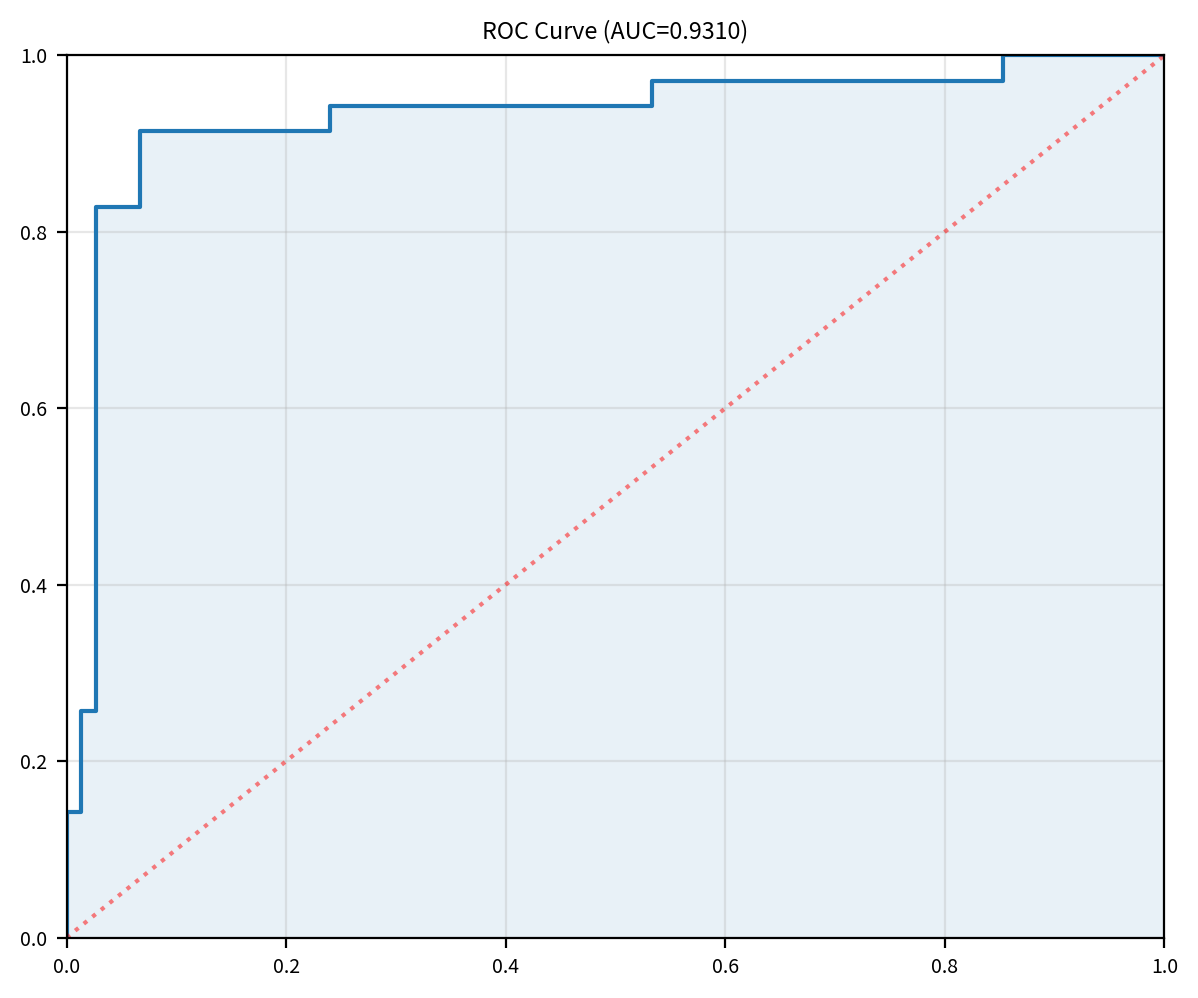

In [67]:
fpr, tpr, _ = roc_curve(y_test, y_pred_proba_1)
auc = roc_auc_score(y_test, y_pred_proba_1)
fig, ax = plt.subplots(1, 1, figsize=(6, 5), dpi=my_dpi)
ax.plot(fpr, tpr)
ax.plot([0, 1], [0, 1], color='red', linestyle=':', alpha=0.5)
ax.fill_between(fpr, tpr, alpha=0.1)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_title(f'ROC Curve (AUC={auc:.4f})')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
plt.close()

## 5. Feature Importance

In [68]:
imp = DataFrame({
    'feature': log_cols,
    'importance': clf.feature_importances_
}).sort_values('importance', ascending=False)
imp

,feature,importance
4,log_Detergents_Paper,0.654299
1,log_Milk,0.085584
6,log_Region,0.065066
2,log_Grocery,0.060937
5,log_Delicassen,0.047067
3,log_Frozen,0.046885
0,log_Fresh,0.040162


C:\Users\bohee\AppData\Local\Temp\ipykernel_6368\1166794653.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sb.barplot(data=imp, x='importance', y='feature', palette='viridis')


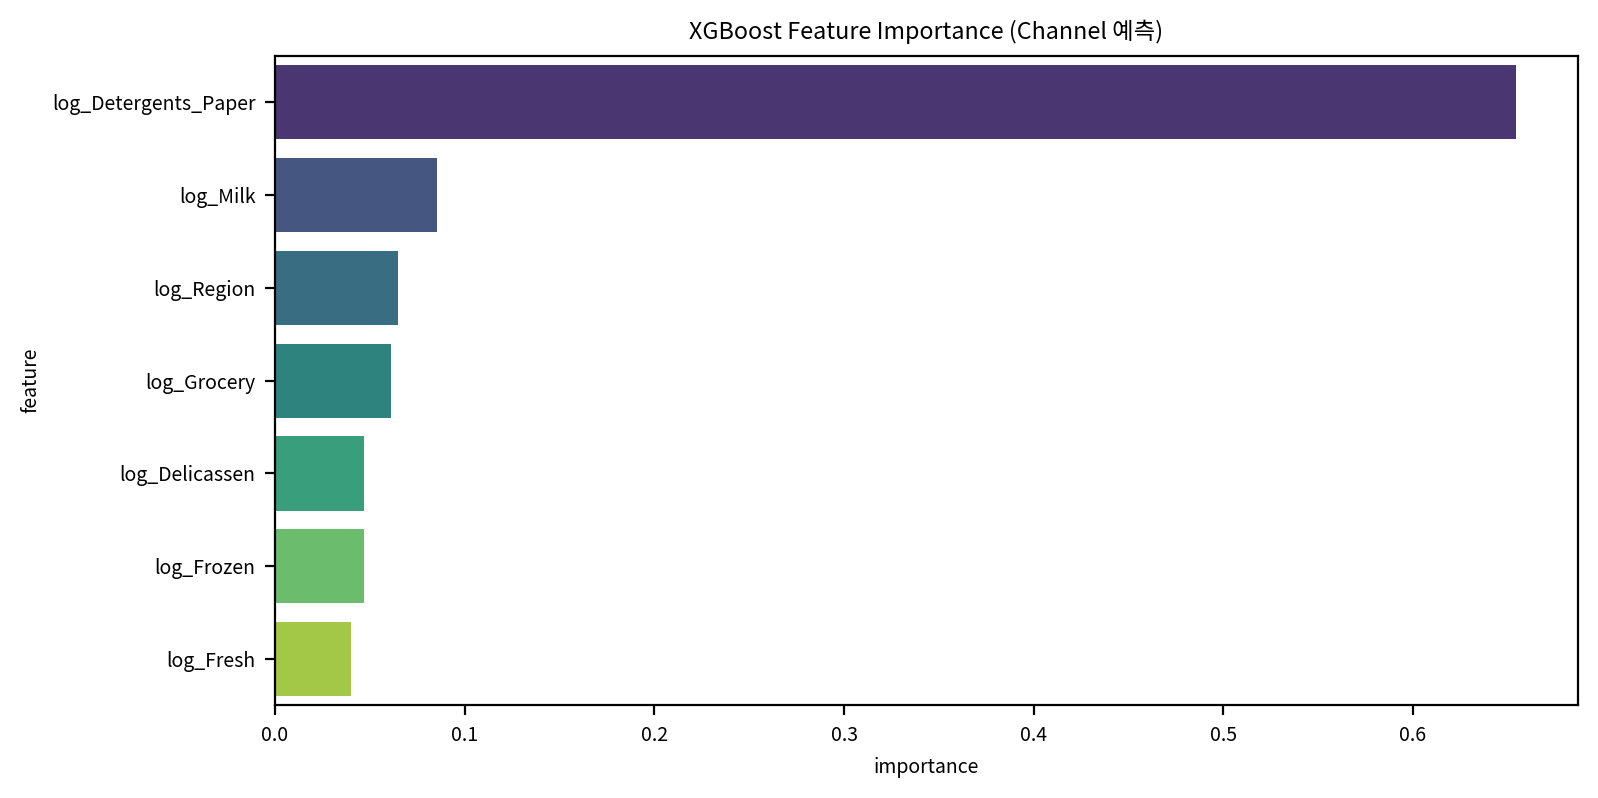

In [69]:
fig, ax = plt.subplots(1, 1, figsize=(8, 4), dpi=my_dpi)
sb.barplot(data=imp, x='importance', y='feature', palette='viridis')
ax.set_title('XGBoost Feature Importance (Channel 예측)')
plt.tight_layout()
plt.show()
plt.close()

## 6. Scaler / XGB 모델 저장 (TabPy·Tableau 시뮬레이터용)

In [70]:
scaler_path = LAB05_DIR / 'wholesale_scaler.pkl'
model_path = LAB05_DIR / 'wholesale_xgb.pkl'

with open(scaler_path, 'wb') as f:
    pickle.dump(scaler, f)
with open(model_path, 'wb') as f:
    pickle.dump(clf, f)

print('저장 완료:', scaler_path)
print('저장 완료:', model_path)

저장 완료: C:\Users\bohee\Documents\GitHub\Machine_learning\[LAB 05] 비지도 학습 - 구매 패턴 기반 고객 군집 분석과 페르소나 도출\wholesale_scaler.pkl
저장 완료: C:\Users\bohee\Documents\GitHub\Machine_learning\[LAB 05] 비지도 학습 - 구매 패턴 기반 고객 군집 분석과 페르소나 도출\wholesale_xgb.pkl


## 7. TabPy 배포용 함수: 원본 수치 → 예측 클래스 & 확률

Tableau 시뮬레이터에서 **원본 구매액(Raw)** 6개를 넘기면,  
1. np.log1p 적용  
2. 저장된 StandardScaler로 스케일  
3. XGBoost predict_proba  
4. **예측 클래스(0/1)** 와 **양성(Channel=2) 확률** 을 리스트로 반환

In [71]:
def predict_customer_channel(Fresh, Milk, Grocery, Frozen, Detergents_Paper, Delicassen):
    """
    TabPy/Tableau에서 호출할 함수.
    인자: 원본 구매액 6개 (각각 리스트 또는 단일 값)
    반환: (예측 클래스 리스트, 양성 확률 리스트)
    """
    def to_arr(x):
        if hasattr(x, '__len__') and not isinstance(x, (str, bytes)):
            return np.asarray(x, dtype=float)
        return np.asarray([float(x)], dtype=float)

    fresh = to_arr(Fresh)
    milk = to_arr(Milk)
    grocery = to_arr(Grocery)
    frozen = to_arr(Frozen)
    det = to_arr(Detergents_Paper)
    deli = to_arr(Delicassen)

    n = max(len(fresh), len(milk), len(grocery), len(frozen), len(det), len(deli))
    if n == 0:
        return [], []
    if len(fresh) == 1 and n > 1: fresh = np.full(n, float(fresh.flat[0]))
    if len(milk) == 1 and n > 1: milk = np.full(n, float(milk.flat[0]))
    if len(grocery) == 1 and n > 1: grocery = np.full(n, float(grocery.flat[0]))
    if len(frozen) == 1 and n > 1: frozen = np.full(n, float(frozen.flat[0]))
    if len(det) == 1 and n > 1: det = np.full(n, float(det.flat[0]))
    if len(deli) == 1 and n > 1: deli = np.full(n, float(deli.flat[0]))

    raw = np.column_stack([fresh, milk, grocery, frozen, det, deli])
    log = np.log1p(raw)
    full = np.hstack([raw, log])
    scaled = scaler.transform(full)
    X_in = scaled[:, 6:12]

    proba = clf.predict_proba(X_in)
    pred_class = clf.predict(X_in)
    proba_positive = proba[:, 1].tolist()

    return pred_class.tolist(), proba_positive

In [72]:
# 검증: 테스트 데이터 몇 개로 호출
raw_test = origin[RAW_COLS].iloc[:5].values
p, prob = predict_customer_channel(
    raw_test[:, 0], raw_test[:, 1], raw_test[:, 2],
    raw_test[:, 3], raw_test[:, 4], raw_test[:, 5]
)
print('예측 클래스:', p)
print('Channel=2 확률:', prob)
print('실제 Channel:', (origin['Channel'].iloc[:5] - 1).tolist())

c:\Users\bohee\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


ValueError: X has 12 features, but StandardScaler is expecting 14 features as input.